# Detectability across the Galactic disk

The most important results plots!

## Imports

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy import units as u
from pathlib import Path

from gaianir_open_clusters.config import RESULTS_DIRECTORY
from gaianir_open_clusters import plots
from gaianir_open_clusters.util import position_to_max_galaxy_distance


plots.setup_matplotlib(no_log=True, latex=True)

In [2]:
detection_results = pd.read_parquet(RESULTS_DIRECTORY / "detection_results.parquet")

In [3]:
missions = (
    "gaianir-l",
    "gaianir-m",
    "gaia_dr5",
    "gaia_dr4",
    "gaia_dr3",
    "gaia_dr3_empirical",
)

## Helpers

### General things

In [67]:
def assign_detection_probabilities(
    detection_results, minimum_stars=100, minimum_ratio=5
):
    """Converts 5D density and number of stars into a detection probability (1 or 0)
    based on assigned settings.
    """
    for m in missions:
        if "empirical" in m:
            continue

        good_ratio = detection_results[f"total_ratio_{m}"] > minimum_ratio
        detection_results[f"probability_{m}"] = np.where(
            detection_results[f"n_stars_{m}"] > minimum_stars,
            (good_ratio).astype(float),
            0.0,
        )

    return detection_results


def calculate_detection_distances(
    cluster, empirical_probability=0.5, return_as_xy=True
):
    """Calculates the distances to which something can be detected."""

    l_values = np.unique(detection_results["l"])
    detectabilities = {mission: [] for mission in missions}
    for l in l_values:
        subsample = detection_results.query(f"cluster=='{cluster}' and l=={l}")
        max_distance = position_to_max_galaxy_distance(l, 20000)

        for m in missions:
            distances, probabilities = (
                subsample[["distance", f"probability_{m}"]].to_numpy().T
            )
            is_below = probabilities < empirical_probability
            false_values = is_below.nonzero()[0]

            # If everything is detected, just set to max distance
            if len(false_values) == 0:
                detectabilities[m].append(max_distance)
                continue

            # If it's never detected, set to zero
            first_false_value = false_values[0]
            if first_false_value == 0:
                detectabilities[m].append(0)
                continue

            # Otherwise, interpolate between the two sides
            slicer = slice(first_false_value - 1, first_false_value + 1)
            detectabilities[m].append(
                np.clip(
                    np.interp(
                        empirical_probability,
                        probabilities[slicer][::-1],
                        distances[slicer][::-1],
                    ),
                    0,
                    max_distance,
                )
            )

    if return_as_xy:
        return detectabilities_to_xy(detectabilities, l_values)
    return detectabilities, l_values


def detectabilities_to_xy(detectabilities, l_values):
    xy_values = {}
    for m in missions:
        coord = (
            SkyCoord(
                l=np.asarray(l_values) * u.deg,
                b=np.zeros_like(l_values) * u.deg,
                distance=np.asarray(detectabilities[m]) * u.pc,
                frame="galactic",
            )
            .transform_to("galactocentric")
            .represent_as("cartesian")
        )  # type: ignore  (fuck pylance)
        x_values = coord.x.value
        y_values = coord.y.value
        x_values = np.append(x_values, x_values[0])
        y_values = np.append(y_values, y_values[0])
        xy_values[m] = [x_values, y_values]
    return xy_values

### Plotting

In [168]:
mission_name = {
    "gaianir-l": "GaiaNIR-Large",
    "gaianir-m": "GaiaNIR-Medium",
    "gaia_dr5": "Gaia DR5",
    "gaia_dr4": "Gaia DR4",
    "gaia_dr3": "Gaia DR3",
    "gaia_dr3_empirical": "Gaia DR3 (HR26)",
}
mission_style = {
    "gaianir-l": dict(color=plots.cycle10[2], ls="-"),
    "gaianir-m": dict(color=plots.cycle10[6], ls="--"),
    "gaia_dr5": dict(color=plots.cycle10[4], ls="-"),
    "gaia_dr4": dict(color=plots.cycle10[7], ls="-"),
    "gaia_dr3": dict(color=plots.cycle10[0], ls="-"),
    "gaia_dr3_empirical": dict(color=plots.cycle10[5], ls="-"),
}
for mission, style in mission_style.items():
    style["label"] = mission_name[mission]


def add_disk_regions(ax):
    ax.add_patch(
        plt.Circle(
            [0, 0],
            radius=15,
            color="#ddd",
            alpha=1.0,
            linewidth=0,
            label="Disk",
            zorder=1,
        )
    )
    ax.add_patch(
        plt.Circle(
            [0, 0],
            radius=20,
            color="#eee",
            alpha=1.0,
            linewidth=0,
            label="Outer disk",
            zorder=0,
        )
    )


def make_detectability_plot(
    detectabilities,
    missions,
    title=None,
    legend_cols=3,
    legend_loc="lower center",
    savefig=None,
    x_max=-np.inf
):
    fig, ax = plt.subplots(figsize=(plots.COLWIDTH, plots.COLWIDTH))

    add_disk_regions(ax)

    x_lims, y_lims = np.asarray((np.inf, x_max)), np.asarray((np.inf, -np.inf))
    for mission in missions:
        xy = detectabilities[mission]
        ax.plot(xy[0] * 1e-3, xy[1] * 1e-3, **mission_style[mission])
        x_lims[0] = np.minimum(xy[0].min(), x_lims[0])
        x_lims[1] = np.maximum(xy[0].max(), x_lims[1])
        y_lims[0] = np.minimum(xy[1].min(), y_lims[0])
        y_lims[1] = np.maximum(xy[1].max(), y_lims[1])

    ax.legend(loc=legend_loc, ncols=legend_cols, fontsize=6)
    ax.set(
        xlabel="X [kpc]",
        ylabel="Y [kpc]",
        xlim=x_lims * 1e-3 * 1.05,
        ylim=y_lims * 1e-3 * 1.05,
        title=title,
    )

    ax.plot([-8.122], [0], 'ko', ms=4, zorder=100)

    if savefig is not None:
        if isinstance(savefig, Path) or isinstance(savefig, str):
            fig.savefig(savefig)
        else:
            for path in savefig:
                fig.savefig(path)


## Plots of individual scenarios

In [169]:
detection_results = assign_detection_probabilities(detection_results)

### Pleiades-like cluster

In [170]:
detectabilities = calculate_detection_distances("pleiades")

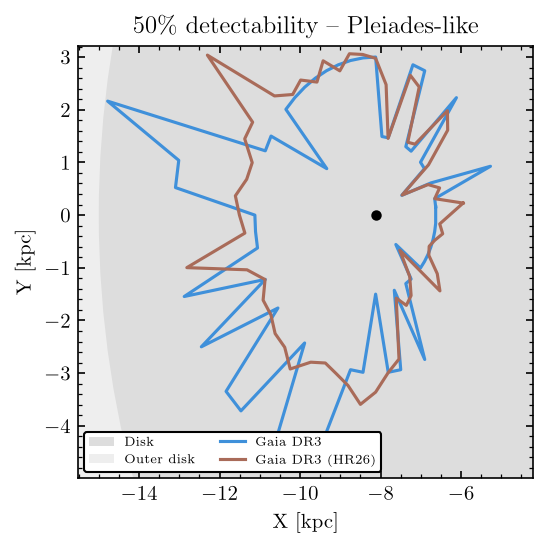

In [171]:
make_detectability_plot(
    detectabilities,
    ("gaia_dr3", "gaia_dr3_empirical"),
    title=r"50\% detectability -- Pleiades-like",
    savefig=plots.FIGS_PRES / "pleiades_detectability_dr3.png",
    legend_cols=2,
    legend_loc="lower left",
    x_max=-4000,
)

<>:4: SyntaxWarning: invalid escape sequence '\%'
<>:4: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_57087/3575450167.py:4: SyntaxWarning: invalid escape sequence '\%'
  title="50\% detectability -- Pleiades-like",


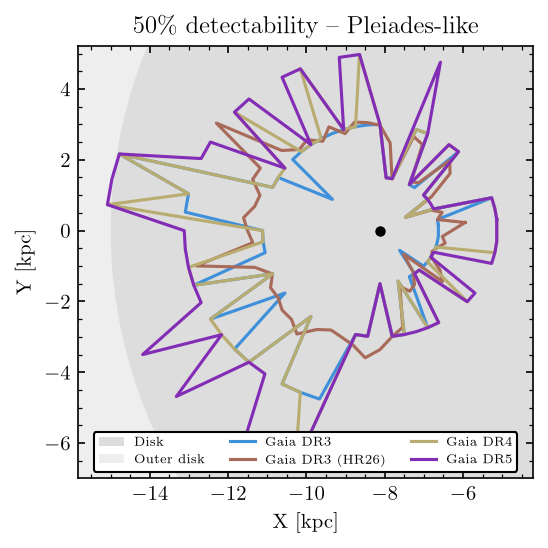

In [173]:
make_detectability_plot(
    detectabilities,
    ("gaia_dr3", "gaia_dr3_empirical", "gaia_dr4", "gaia_dr5"),
    title="50\% detectability -- Pleiades-like",
    savefig=plots.FIGS_PRES / "pleiades_detectability_gaia.png",
    legend_cols=3,
    x_max=-4000,
)

<>:4: SyntaxWarning: invalid escape sequence '\%'
<>:4: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_57087/3428982966.py:4: SyntaxWarning: invalid escape sequence '\%'
  title="50\% detectability -- Pleiades-like",


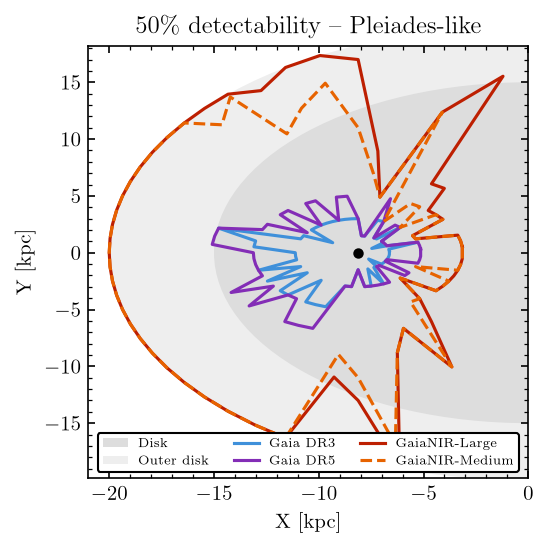

In [174]:
make_detectability_plot(
    detectabilities,
    ("gaia_dr3", "gaia_dr5", "gaianir-l", "gaianir-m"),
    title="50\% detectability -- Pleiades-like",
    savefig=plots.FIGS_PRES / "pleiades_detectability_gaianir.png",
    legend_cols=3,
    x_max=0,
)

### Embedded cluster

In [175]:
detectabilities = calculate_detection_distances("embedded")

<>:4: SyntaxWarning: invalid escape sequence '\%'
<>:4: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_57087/3980523233.py:4: SyntaxWarning: invalid escape sequence '\%'
  title="50\% detectability -- Embedded cluster",


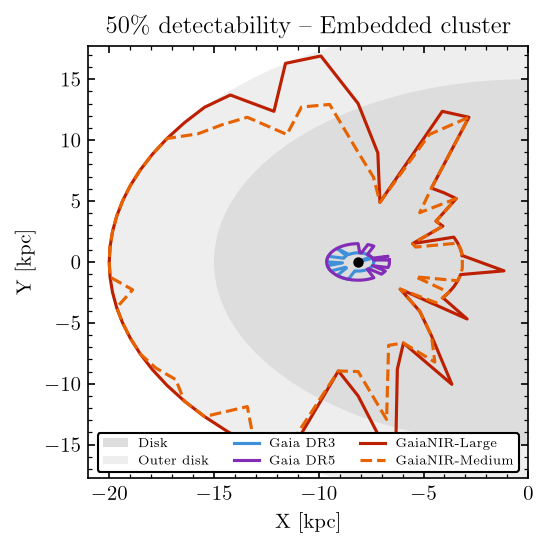

In [176]:
make_detectability_plot(
    detectabilities,
    ("gaia_dr3", "gaia_dr5", "gaianir-l", "gaianir-m"),
    title="50\% detectability -- Embedded cluster",
    savefig=plots.FIGS_PRES / "embedded_detectability_gaianir.png",
    legend_cols=3,
    x_max=0,
)

### Berkeley 29

In [177]:
detectabilities = calculate_detection_distances("berkeley_29")

In [189]:
np.linspace(2000, 20000, num=37)

array([ 2000.,  2500.,  3000.,  3500.,  4000.,  4500.,  5000.,  5500.,
        6000.,  6500.,  7000.,  7500.,  8000.,  8500.,  9000.,  9500.,
       10000., 10500., 11000., 11500., 12000., 12500., 13000., 13500.,
       14000., 14500., 15000., 15500., 16000., 16500., 17000., 17500.,
       18000., 18500., 19000., 19500., 20000.])

<>:4: SyntaxWarning: invalid escape sequence '\%'
<>:4: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_57087/3842433253.py:4: SyntaxWarning: invalid escape sequence '\%'
  title="50\% detectability -- Berkeley 29-like",


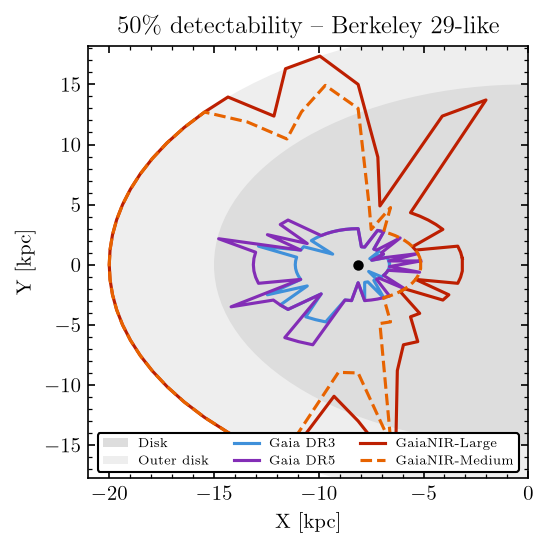

In [178]:
make_detectability_plot(
    detectabilities,
    ("gaia_dr3", "gaia_dr5", "gaianir-l", "gaianir-m"),
    title="50\% detectability -- Berkeley 29-like",
    savefig=plots.FIGS_PRES / "berkeley_29_detectability_gaianir.png",
    legend_cols=3,
    x_max=0,
)